# EMRI Waveform Explorer

Set the intrinsic (and optionally extrinsic) source parameters, then run the cells
to generate and compare **fewtrax** and **FEW** waveforms in both the time domain
and the frequency domain.

### Parameters
| Symbol | Meaning | Typical range |
|--------|---------|---------------|
| `M` | Primary BH mass [M☉] | 10⁵ – 10⁷ |
| `mu` | Secondary mass [M☉] | 1 – 100 |
| `a` | Dimensionless spin | 0 – 0.99 |
| `p0` | Initial semi-latus rectum [M] | p_sep + 1 – 20 |
| `e0` | Initial eccentricity | 0 – 0.8 |
| `x0` | Inclination cosine | +1 (prograde) / −1 (retrograde) |
| `T` | Observation time [yr] | 0.01 – 2 |
| `dt` | Sampling interval [s] | 5 – 100 |

In [1]:
import sys, os
from pathlib import Path

# Make sure the comparison utils are importable
comparison_dir = Path(".").resolve()
if str(comparison_dir) not in sys.path:
    sys.path.insert(0, str(comparison_dir))

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

from utils import find_data_dir

DATA_DIR = find_data_dir()
print(f"FEW data directory: {DATA_DIR}")

FEW data directory: /Users/bertd/Documents/PhD/LISA/Codes/FastEMRIWaveforms/src/few/data


## Initialise waveform generators

In [2]:
# waveform settings
mode_threshold = 1e-7   # relative power threshold for mode selection
dense_steps    = 100    # sparse trajectory points fed to the ODE

In [3]:
# ── fewtrax 
from fewtrax import KerrEccentricEquatorialWaveform

wf_ft = KerrEccentricEquatorialWaveform(
    data_dir=DATA_DIR,
    mode_selection_threshold=mode_threshold,
    dense_steps=dense_steps,
)
print("fewtrax generator ready.")

# ── FEW
from few.waveform import GenerateEMRIWaveform

wf_few = GenerateEMRIWaveform("FastKerrEccentricEquatorialFlux")
print("FEW generator ready.")

fewtrax generator ready.
FEW generator ready.


## Set parameters

In [4]:
# intrinsic
M   = 1e6      # primary BH mass  
mu  = 10.0     # secondary mass   
a   = 0.998      # dimensionless spin
p0  = 14.0     # initial semi-latus rectum  [M]
e0  = 0.8      # initial eccentricity
x0  = 1.0      # inclination cosine (+1 prograde)

#Initial orbital phases [rad]
Phi_phi0   = 0.0
Phi_theta0 = 0.0
Phi_r0     = 0.0

# extrinsic
dist  = 1.0    # luminosity distance  [Gpc]
qS    = 0.2    # sky colatitude of source  [rad]
phiS  = 0.2    # sky longitude of source   [rad]
qK    = 0.8    # spin-axis polar angle     [rad]
phiK  = 0.8    # spin-axis azimuthal angle [rad]

# timing
T   = 0.2      # observation time  [yr]
dt  = 10.0     # sampling interval [s]

## Generate waveforms

In [5]:
call_kwargs = dict(
    M=M, mu=mu, a=a, p0=p0, e0=e0, x0=x0,
    dist=dist, qS=qS, phiS=phiS, qK=qK, phiK=phiK,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0,
    T=T, dt=dt,
)

# fewtrax
hp_ft, hx_ft, sparse = wf_ft(**call_kwargs, return_sparse=True)
hp_ft = np.asarray(hp_ft)
hx_ft = np.asarray(hx_ft)
n_modes_ft = sparse["teuk_modes"].shape[1]
print(f"fewtrax: {len(hp_ft)} samples,  {n_modes_ft} modes selected")

# FEW
few_args = [M, mu, a, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
h_few = wf_few(*few_args, T=T, dt=dt, mode_selection_threshold=mode_threshold)
hp_few = np.real(np.asarray(h_few))
hx_few = -np.imag(np.asarray(h_few))
print(f"FEW:     {len(hp_few)} samples")

fewtrax: 631164 samples,  861 modes selected
FEW:     631163 samples


## Overlap and mismatch

> Large mismatch indicates the
> waveforms are out of phase — the most common cause is a drift in
> the accumulated orbital phase between the two integrators.

In [6]:
def white_noise_overlap(h1, h2):
    """Normalised inner product (flat power spectrum)."""
    n = min(len(h1), len(h2))
    a = h1[:n].astype(float)
    b = h2[:n].astype(float)
    na = np.sqrt(np.dot(a, a))
    nb = np.sqrt(np.dot(b, b))
    if na < 1e-40 or nb < 1e-40:
        return 0.0
    return float(abs(np.dot(a, b)) / (na * nb))

ov_hp = white_noise_overlap(hp_few, hp_ft)
ov_hx = white_noise_overlap(hx_few, hx_ft)
mm_hp = 1.0 - ov_hp
mm_hx = 1.0 - ov_hx

n = min(len(hp_few), len(hp_ft))
rms_hp = float(np.sqrt(np.mean((hp_ft[:n] - hp_few[:n])**2)) /
               (np.sqrt(np.mean(hp_few[:n]**2)) + 1e-40))
print('========= White noise PSD model ===========')
print(f"Overlap  h+  = {ov_hp:.6f}    Mismatch = {mm_hp:.4e}")
print(f"Overlap  hx  = {ov_hx:.6f}    Mismatch = {mm_hx:.4e}")
print(f"h+ RMS relative error = {rms_hp:.3e}")

========= White noise PSD model ===========
Overlap  h+  = 1.000000    Mismatch = 2.9754e-07
Overlap  hx  = 1.000000    Mismatch = 3.0876e-07
h+ RMS relative error = 7.775e-04


In [7]:
def LISA_overlap(h1, h2):
    """Normalised inner product (LISA power spectrum)."""
    n = min(len(h1), len(h2))
    a = h1[:n].astype(float)
    b = h2[:n].astype(float)
    na = np.sqrt(np.dot(a, a))
    nb = np.sqrt(np.dot(b, b))
    if na < 1e-40 or nb < 1e-40:
        return 0.0
    return float(abs(np.dot(a, b)) / (na * nb))

ov_hp = white_noise_overlap(hp_few, hp_ft)
ov_hx = white_noise_overlap(hx_few, hx_ft)
mm_hp = 1.0 - ov_hp
mm_hx = 1.0 - ov_hx

n = min(len(hp_few), len(hp_ft))
rms_hp = float(np.sqrt(np.mean((hp_ft[:n] - hp_few[:n])**2)) /
               (np.sqrt(np.mean(hp_few[:n]**2)) + 1e-40))

print('========= LISA PSD model ===========')
print(f"Overlap  h+  = {ov_hp:.6f}    Mismatch = {mm_hp:.4e}")
print(f"Overlap  hx  = {ov_hx:.6f}    Mismatch = {mm_hx:.4e}")
print(f"h+ RMS relative error = {rms_hp:.3e}")

========= LISA PSD model ===========
Overlap  h+  = 1.000000    Mismatch = 2.9754e-07
Overlap  hx  = 1.000000    Mismatch = 3.0876e-07
h+ RMS relative error = 7.775e-04


## Time-domain plots

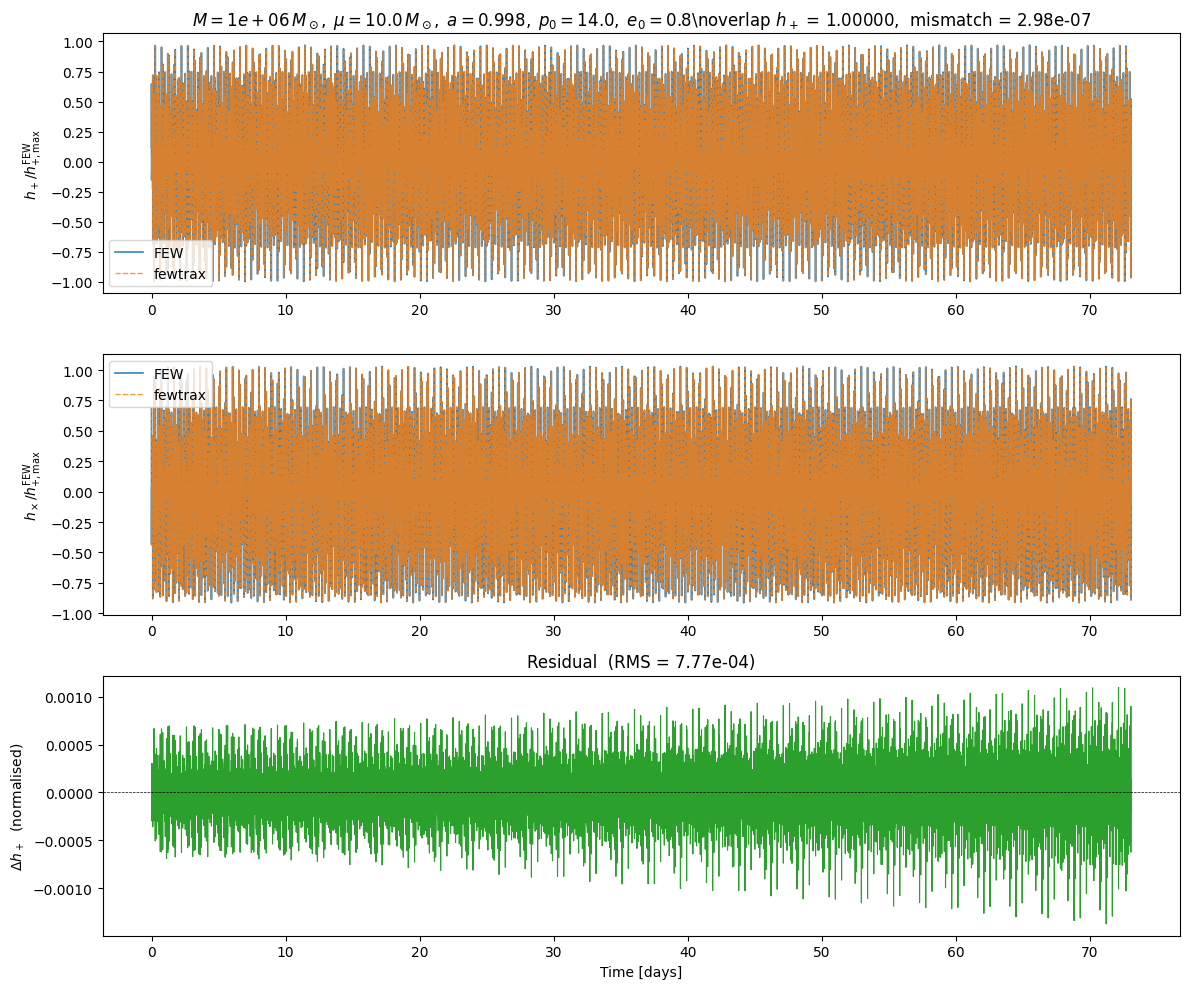

In [8]:
n_plot = min(len(hp_few), len(hp_ft))
t_days = np.arange(n_plot) * dt / 86400.0

scale = 1.0 / max(float(np.max(np.abs(hp_few[:n_plot]))), 1e-40)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# h+
axes[0].plot(t_days, hp_few[:n_plot] * scale, label="FEW",     lw=1.2, alpha=0.9)
axes[0].plot(t_days, hp_ft[:n_plot]  * scale, label="fewtrax", lw=1.0, ls="--", alpha=0.8)
axes[0].set_ylabel(r"$h_+ / h_{+,\max}^{\rm FEW}$")
axes[0].set_title(
    fr"$M={M:.0e}\,M_\odot,\; \mu={mu}\,M_\odot,\; a={a},\; p_0={p0},\; e_0={e0}$\n"
    fr"overlap $h_+$ = {ov_hp:.5f},  mismatch = {mm_hp:.2e}"
)
axes[0].legend()

# hx
axes[1].plot(t_days, hx_few[:n_plot] * scale, label="FEW",     lw=1.2, alpha=0.9)
axes[1].plot(t_days, hx_ft[:n_plot]  * scale, label="fewtrax", lw=1.0, ls="--", alpha=0.8)
axes[1].set_ylabel(r"$h_\times / h_{+,\max}^{\rm FEW}$")
axes[1].legend()

# Residual
residual = (hp_ft[:n_plot] - hp_few[:n_plot]) * scale
axes[2].plot(t_days, residual, lw=0.8, color="C2")
axes[2].axhline(0, color="k", lw=0.5, ls="--")
axes[2].set_ylabel(r"$\Delta h_+$  (normalised)")
axes[2].set_xlabel("Time [days]")
axes[2].set_title(f"Residual  (RMS = {rms_hp:.2e})")

plt.tight_layout()
plt.show()

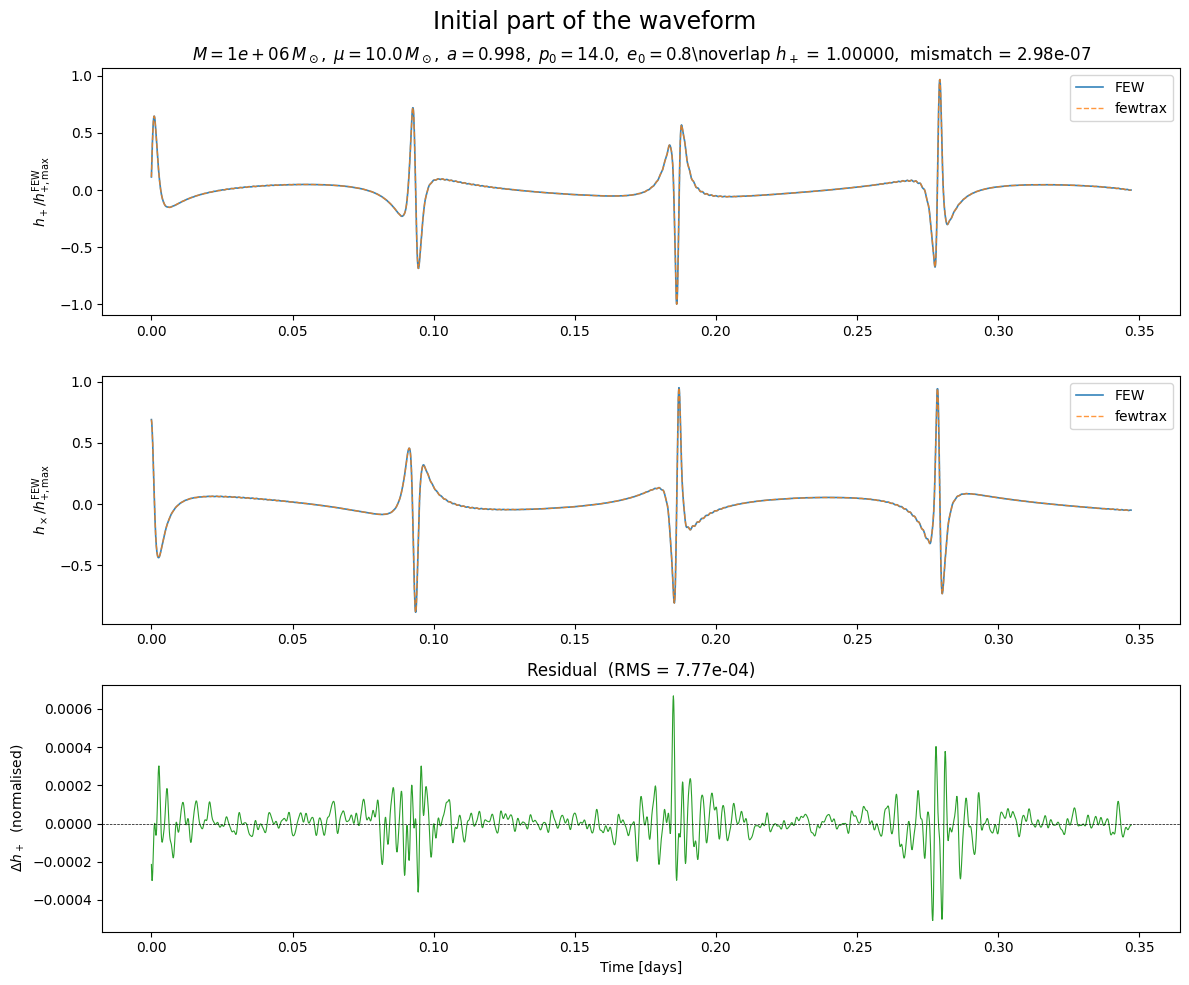

In [9]:
# Initial part of the inspiral
n_plot = min(len(hp_few), len(hp_ft))
n_plot = 3000
t_days = np.arange(n_plot) * dt / 86400.0

scale = 1.0 / max(float(np.max(np.abs(hp_few[:n_plot]))), 1e-40)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# h+
axes[0].plot(t_days, hp_few[:n_plot] * scale, label="FEW",     lw=1.2, alpha=0.9)
axes[0].plot(t_days, hp_ft[:n_plot]  * scale, label="fewtrax", lw=1.0, ls="--", alpha=0.8)
axes[0].set_ylabel(r"$h_+ / h_{+,\max}^{\rm FEW}$")
axes[0].set_title(
    fr"$M={M:.0e}\,M_\odot,\; \mu={mu}\,M_\odot,\; a={a},\; p_0={p0},\; e_0={e0}$\n"
    fr"overlap $h_+$ = {ov_hp:.5f},  mismatch = {mm_hp:.2e}"
)
axes[0].legend()

# hx
axes[1].plot(t_days, hx_few[:n_plot] * scale, label="FEW",     lw=1.2, alpha=0.9)
axes[1].plot(t_days, hx_ft[:n_plot]  * scale, label="fewtrax", lw=1.0, ls="--", alpha=0.8)
axes[1].set_ylabel(r"$h_\times / h_{+,\max}^{\rm FEW}$")
axes[1].legend()

# Residual
residual = (hp_ft[:n_plot] - hp_few[:n_plot]) * scale
axes[2].plot(t_days, residual, lw=0.8, color="C2")
axes[2].axhline(0, color="k", lw=0.5, ls="--")
axes[2].set_ylabel(r"$\Delta h_+$  (normalised)")
axes[2].set_xlabel("Time [days]")
axes[2].set_title(f"Residual  (RMS = {rms_hp:.2e})")

fig.suptitle('Initial part of the waveform', fontsize=17)

plt.tight_layout()
plt.show()

In [10]:
length_ft = len(hp_ft)
length_ft

631164

In [11]:
length_few = len(hp_few)
length_few

631163

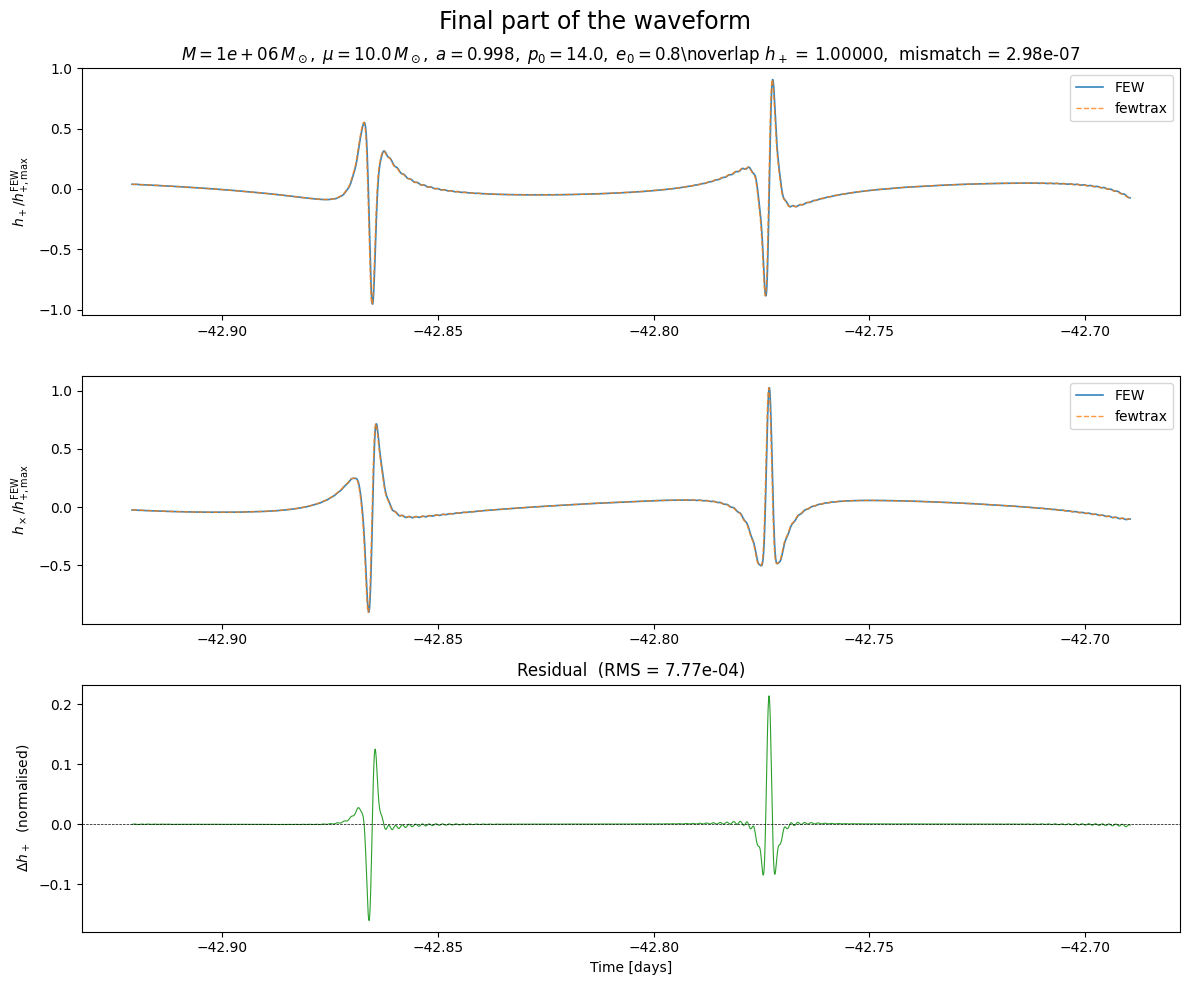

In [12]:
# Final part of inspiral
n_plot = min(len(hp_few), len(hp_ft))
n_plot = 2000
start = min(length_ft, length_few) - n_plot - 1000000
t_days = (start + np.arange(n_plot)) * dt / 86400.0

scale = 1.0 / max(float(np.max(np.abs(hp_few[:n_plot]))), 1e-40)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# h+
axes[0].plot(t_days, hp_few[start:start+n_plot] * scale, label="FEW",     lw=1.2, alpha=0.9)
axes[0].plot(t_days, hp_ft[start:start+n_plot]  * scale, label="fewtrax", lw=1.0, ls="--", alpha=0.8)
axes[0].set_ylabel(r"$h_+ / h_{+,\max}^{\rm FEW}$")
axes[0].set_title(
    fr"$M={M:.0e}\,M_\odot,\; \mu={mu}\,M_\odot,\; a={a},\; p_0={p0},\; e_0={e0}$\n"
    fr"overlap $h_+$ = {ov_hp:.5f},  mismatch = {mm_hp:.2e}"
)
axes[0].legend()

# hx
axes[1].plot(t_days, hx_few[start:start+n_plot] * scale, label="FEW",     lw=1.2, alpha=0.9)
axes[1].plot(t_days, hx_ft[start:start+n_plot]  * scale, label="fewtrax", lw=1.0, ls="--", alpha=0.8)
axes[1].set_ylabel(r"$h_\times / h_{+,\max}^{\rm FEW}$")
axes[1].legend()

# Residual
residual = (hp_ft[start:start+n_plot] - hp_few[start:start+n_plot]) * scale
axes[2].plot(t_days, residual, lw=0.8, color="C2")
axes[2].axhline(0, color="k", lw=0.5, ls="--")
axes[2].set_ylabel(r"$\Delta h_+$  (normalised)")
axes[2].set_xlabel("Time [days]")
axes[2].set_title(f"Residual  (RMS = {rms_hp:.2e})")

fig.suptitle('Final part of the waveform', fontsize=17)

plt.tight_layout()
plt.show()

## Frequency-domain plots

A window is applied before the FFT to reduce spectral leakage. The signal is zero-padded to the next power of two for better frequency resolution.

In [19]:
from fewtrax.utils.transforms import to_frequency_domain

def fd(arr, window="tukey", zero_pad=True):
    f, h_tilde = to_frequency_domain(
        jnp.asarray(arr[:], dtype=jnp.float64),
        dt=dt, window=window, zero_pad=zero_pad,
    )
    return np.asarray(f), np.abs(np.asarray(h_tilde))

f_hp_few, amp_hp_few = fd(hp_few)
f_hp_ft,  amp_hp_ft  = fd(hp_ft)
f_hx_few, amp_hx_few = fd(hx_few)
f_hx_ft,  amp_hx_ft  = fd(hx_ft)

res = hp_ft[:-1]- hp_few
f_res_hp, amp_res_hp = fd(res)
f_res_hx,  amp_res_hx  = fd(res)

f_nyq   = 0.5 / dt
f_min_p = max(f_hp_few[1], 1e-5)

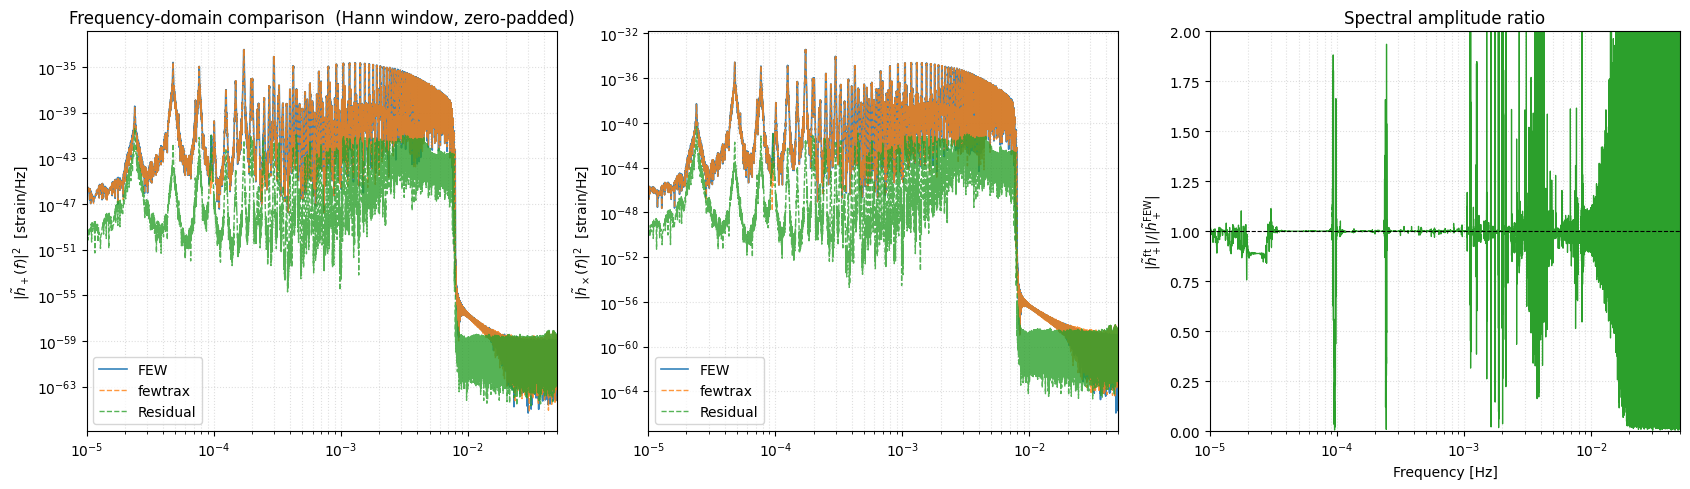

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# hplus
axes[0].loglog(f_hp_few, amp_hp_few**2, label="FEW",     lw=1.2, alpha=0.9)
axes[0].loglog(f_hp_ft,  amp_hp_ft**2,  label="fewtrax", lw=1.0, ls="--", alpha=0.8)
axes[0].loglog(f_res_hp,  amp_res_hp**2,  label="Residual", lw=1.0, ls="--", alpha=0.8)
axes[0].set_xlim(f_min_p, f_nyq)
axes[0].set_ylabel(r"$|\tilde{h}_+(f)|^2$  [strain/Hz]")
axes[0].set_title("Frequency-domain comparison  (Hann window, zero-padded)")
axes[0].legend()
axes[0].grid(True, which="both", ls=":", alpha=0.4)

#hcross
axes[1].loglog(f_hx_few, amp_hx_few**2, label="FEW",     lw=1.2, alpha=0.9)
axes[1].loglog(f_hx_ft,  amp_hx_ft**2,  label="fewtrax", lw=1.0, ls="--", alpha=0.8)
axes[1].loglog(f_res_hx,  amp_res_hx**2,  label="Residual", lw=1.0, ls="--", alpha=0.8)
axes[1].set_xlim(f_min_p, f_nyq)
axes[1].set_ylabel(r"$|\tilde{h}_\times(f)|^2$  [strain/Hz]")
axes[1].legend()
axes[1].grid(True, which="both", ls=":", alpha=0.4)

# Amplitude ratio
amp_ft_interp = np.interp(f_hp_few, f_hp_ft, amp_hp_ft)
with np.errstate(divide="ignore", invalid="ignore"):
    ratio = np.where(amp_hp_few > 1e-50, amp_ft_interp / amp_hp_few, np.nan)
axes[2].semilogx(f_hp_few, ratio, lw=0.9, color="C2")
axes[2].axhline(1.0, color="k", lw=0.8, ls="--")
axes[2].set_xlim(f_min_p, f_nyq)
axes[2].set_ylim(0, 2)
axes[2].set_ylabel(r"$|\tilde{h}_+^{\rm ft}| / |\tilde{h}_+^{\rm FEW}|$")
axes[2].set_xlabel("Frequency [Hz]")
axes[2].set_title("Spectral amplitude ratio")
axes[2].grid(True, which="both", ls=":", alpha=0.4)

plt.tight_layout()
plt.show()

## Trajectory comparison

Both integrators accumulate the orbital phase **without wrapping** into [0, 2π].
Φ_φ grows monotonically — a linear trend in the difference panel indicates a
constant frequency offset between the two implementations.

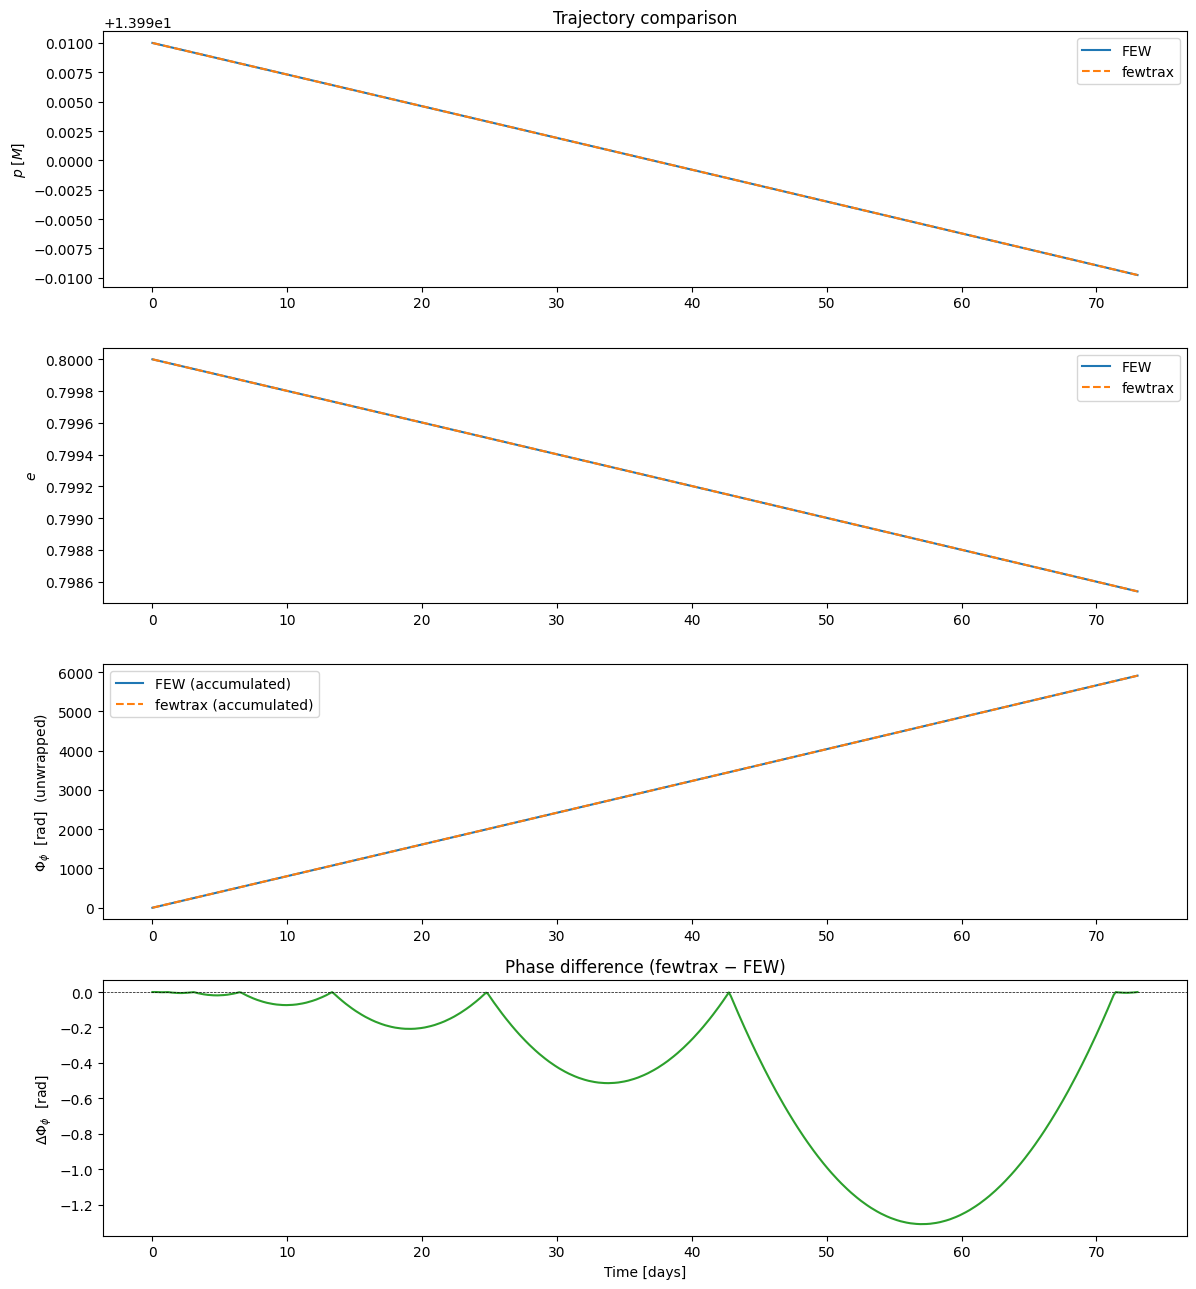

In [15]:
from few.trajectory.inspiral import EMRIInspiral as FEWInspiral
from fewtrax.data.loader import load_flux_data
from fewtrax.trajectory import run_inspiral

# FEW trajectory
traj_few = FEWInspiral(func="KerrEccEqFlux")
res_few = traj_few(M, mu, a, p0, e0, x0, T=T, dt=dt)
t_few_s, p_few, e_few = np.asarray(res_few[0]), np.asarray(res_few[1]), np.asarray(res_few[2])
Phi_phi_few = np.asarray(res_few[4])

# fewtrax trajectory
flux_data = load_flux_data(DATA_DIR)
t_ft_s, p_ft, e_ft, Phi_phi_ft, _, _ = (
    np.asarray(r) for r in run_inspiral(
        a=a, p0=p0, e0=e0, T=T, flux_data=flux_data,
        M=M, mu=mu, dt=dt, x0=x0,
        Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0,
        dense_steps=200,
    )
)
Phi_phi_ft_adj = Phi_phi_ft - Phi_phi0   # align starting phase

t_few_d = t_few_s / 86400.0
t_ft_d  = t_ft_s  / 86400.0

# Common grid for phase difference
t_lo = max(t_few_d[0], t_ft_d[0])
t_hi = min(t_few_d[-1], t_ft_d[-1])
t_c  = np.linspace(t_lo, t_hi, 500)
delta_phi = np.interp(t_c, t_ft_d, Phi_phi_ft_adj) - np.interp(t_c, t_few_d, Phi_phi_few)

fig, axes = plt.subplots(4, 1, figsize=(12, 13), sharex=False)

axes[0].plot(t_few_d, p_few, label="FEW"); axes[0].plot(t_ft_d, p_ft, ls="--", label="fewtrax")
axes[0].set_ylabel(r"$p\;[M]$"); axes[0].legend(); axes[0].set_title("Trajectory comparison")

axes[1].plot(t_few_d, e_few, label="FEW"); axes[1].plot(t_ft_d, e_ft, ls="--", label="fewtrax")
axes[1].set_ylabel(r"$e$"); axes[1].legend()

axes[2].plot(t_few_d, Phi_phi_few,    label="FEW (accumulated)")
axes[2].plot(t_ft_d,  Phi_phi_ft_adj, ls="--", label="fewtrax (accumulated)")
axes[2].set_ylabel(r"$\Phi_\phi$  [rad]  (unwrapped)")
axes[2].legend()

axes[3].plot(t_c, delta_phi, color="C2"); axes[3].axhline(0, color="k", lw=0.5, ls="--")
axes[3].set_ylabel(r"$\Delta\Phi_\phi$  [rad]")
axes[3].set_xlabel("Time [days]")
axes[3].set_title("Phase difference (fewtrax − FEW)")

plt.tight_layout()
plt.show()

## Mismatch evolution through time

Compute the mismatch on an increasingly long prefix `h[0:n]` of the waveform.
Log-spaced evaluation points keep the computation fast even for million-sample arrays.
A rising mismatch indicates that phase errors accumulate over time; a flat curve
suggests a fixed amplitude/polarisation offset rather than a phase drift.

In [16]:
def mismatch_vs_time(h1, h2, dt, n_points=300, min_days=1.0):
    """
    Compute the mismatch between h1 and h2 on the prefix h[0:n] for
    logarithmically spaced values of n.

    Parameters
    ----------
    h1, h2    : array_like   – waveform arrays (same sampling rate dt)
    dt        : float        – sampling interval [s]
    n_points  : int          – number of evaluation points
    min_days  : float        – minimum segment length [days]

    Returns
    -------
    t_days : ndarray  – end-time of each segment [days]
    mm     : ndarray  – mismatch = 1 − |⟨h1,h2⟩| / (‖h1‖ ‖h2‖)
    """
    n_total = min(len(h1), len(h2))
    n_min   = max(2, int(min_days * 86400.0 / dt))

    ns = np.unique(
        np.round(np.logspace(np.log10(n_min), np.log10(n_total), n_points)).astype(int)
    )
    ns = np.clip(ns, 2, n_total)

    a_full = np.asarray(h1[:n_total], dtype=float)
    b_full = np.asarray(h2[:n_total], dtype=float)

    mismatches = np.empty(len(ns))
    for i, n in enumerate(ns):
        a = a_full[:n]
        b = b_full[:n]
        na = np.sqrt(np.dot(a, a))
        nb = np.sqrt(np.dot(b, b))
        if na < 1e-40 or nb < 1e-40:
            mismatches[i] = np.nan
        else:
            mismatches[i] = 1.0 - float(abs(np.dot(a, b)) / (na * nb))

    t_days = ns * dt / 86400.0
    return t_days, mismatches

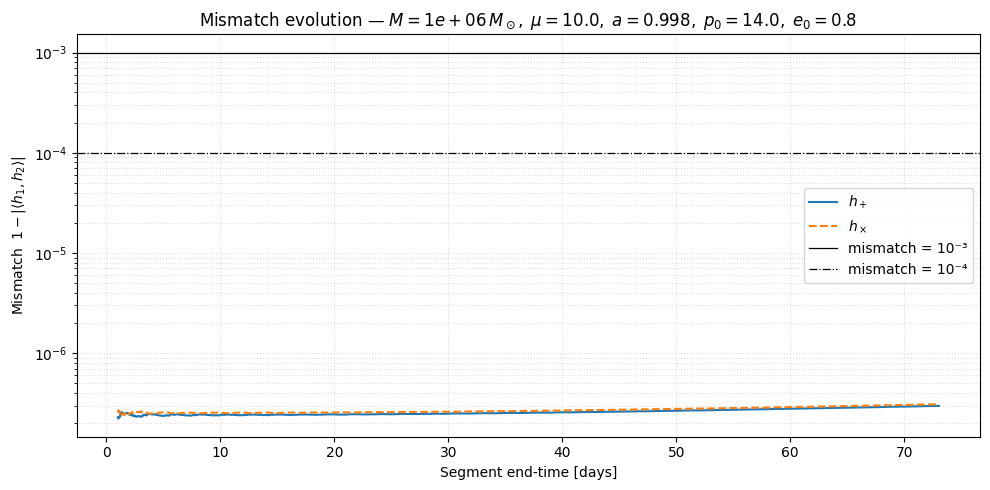

Final mismatch  h+ : 2.9754e-07
Final mismatch  hx : 3.0876e-07


In [17]:
t_mm, mm_hp = mismatch_vs_time(hp_few, hp_ft, dt)
_,    mm_hx = mismatch_vs_time(hx_few, hx_ft, dt)

fig, ax = plt.subplots(figsize=(10, 5))

ax.semilogy(t_mm, mm_hp, lw=1.5, label=r"$h_+$")
ax.semilogy(t_mm, mm_hx, lw=1.5, ls="--", label=r"$h_\times$")

ax.axhline(1e-3, color="black", lw=0.9, ls="-", label="mismatch = 10⁻³")
ax.axhline(1e-4, color="black", lw=0.9, ls="-.", label="mismatch = 10⁻⁴")

ax.set_xlabel("Segment end-time [days]")
ax.set_ylabel("Mismatch  $1 - |\\langle h_1, h_2\\rangle|$")
ax.set_title(
    fr"Mismatch evolution — "
    fr"$M={M:.0e}\,M_\odot,\;\mu={mu},\;a={a},\;p_0={p0},\;e_0={e0}$"
)
ax.legend()
ax.grid(True, which="both", ls=":", alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Final mismatch  h+ : {mm_hp[-1]:.4e}")
print(f"Final mismatch  hx : {mm_hx[-1]:.4e}")